# TD5 Partie 2 : Knowledge Graph Embedding (KGE)



### Installation

In [3]:
!pip install scikit-learn


  Using cached scikit_learn-1.0.2-cp37-cp37m-win_amd64.whl (7.1 MB)
  Using cached numpy-1.21.6-cp37-cp37m-win_amd64.whl (14.0 MB)
  Using cached scipy-1.7.3-cp37-cp37m-win_amd64.whl (34.1 MB)
     ------------------------------------ 302.2/302.2 kB 549.8 kB/s eta 0:00:00


In [4]:
!pip install torch

  Using cached torch-1.13.1-cp37-cp37m-win_amd64.whl (162.6 MB)


In [9]:
!pip install class-resolver click click-default-group dataclasses-json docdata more-click more-itertools optuna pystow pyyaml tabulate tqdm rexmex

  Using cached class_resolver-0.4.3-py3-none-any.whl (25 kB)
  Using cached click-8.1.8-py3-none-any.whl (98 kB)
  Using cached click_default_group-1.2.4-py2.py3-none-any.whl (4.1 kB)
  Using cached dataclasses_json-0.6.7-py3-none-any.whl (28 kB)
     -------------------------------------- 54.2/54.2 kB 467.7 kB/s eta 0:00:00
  Using cached optuna-4.0.0-py3-none-any.whl (362 kB)
  Using cached pystow-0.5.6-py3-none-any.whl (32 kB)
  Using cached PyYAML-6.0.1-cp37-cp37m-win_amd64.whl (153 kB)
  Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached rexmex-0.1.3.tar.gz (21 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pykeen 1.8.1 requires sklearn, which is not installed.


In [11]:
import os
os.environ["SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL"] = "True"
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for sklearn: filename=sklearn-0.0.post12-py3-none-any.whl size=2197 sha256=068e281c7d8a06164e6ba4eb1fce3d27f9fbe8ca3288a958d3eb285fc96a376e
  Stored in directory: c:\users\sandy\appdata\local\pip\cache\wheels\64\dc\1e\c66e5bd0c88ff5ab9d6c6fdcc90f20aa984988da33f560e9bb
Successfully built sklearn


In [12]:
!pip install pykeen

In [6]:
!pip install matplotlib

  Using cached matplotlib-3.5.3-cp37-cp37m-win_amd64.whl (7.2 MB)
     ---------------------------------------- 2.5/2.5 MB 588.0 kB/s eta 0:00:00
     -------------------------------------- 55.8/55.8 kB 484.6 kB/s eta 0:00:00
     ------------------------------------ 965.4/965.4 kB 459.4 kB/s eta 0:00:00


### Imports

In [13]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random
import json

from pykeen.pipeline import pipeline
from pykeen.triples import TriplesFactory
from sklearn.manifold import TSNE

CHEMIN = "C:/Users/sandy/OneDrive/Desktop/Cours A4/Web Datamining/TD4_Project/"

print(f"PyTorch version  : {torch.__version__}")
print(f"GPU disponible   : {torch.cuda.is_available()}")
print(" OK")

C:\Users\sandy\anaconda3\envs\rstudio\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version  : 1.13.1+cpu
GPU disponible   : False
 OK


### 1. Préparation des données

On charge `expanded_kb.nt` et on nettoie les triplets avant l'entraînement.


In [14]:
# Chargement et nettoyage des triplets
triplets_propres = []
vus = set()

with open(CHEMIN + "expanded_kb.nt", "r", encoding="utf-8") as f:
    for ligne in f:
        ligne = ligne.strip()
        if not ligne or ligne.startswith("#"):
            continue

        parties = ligne.rstrip(" .").split(" ", 2)
        if len(parties) < 3:
            continue

        sujet, predicat, objet = parties[0], parties[1], parties[2].strip()

        # On garde seulement les triplets URI->URI (pas les litteraux)
        if not objet.startswith("<"):
            continue

        # Nettoyage des URIs (suppression des < >)
        s = sujet.strip("<>")
        p = predicat.strip("<>")
        o = objet.strip("<>")

        # Suppression des doublons
        cle = (s, p, o)
        if cle in vus:
            continue
        vus.add(cle)

        # Suppression des URIs malformees
        if not all(uri.startswith("http") for uri in [s, p, o]):
            continue

        triplets_propres.append((s, p, o))

print(f"Triplets charges     : {len(triplets_propres)}")
print(f"Entites uniques      : {len(set([t[0] for t in triplets_propres] + [t[2] for t in triplets_propres]))}")
print(f"Relations uniques    : {len(set([t[1] for t in triplets_propres]))}")

Triplets charges     : 70953
Entites uniques      : 18278
Relations uniques    : 56


### Ce qu'on observe

Après nettoyage on ne garde que les triplets URI→URI car les modèles KGE
ne peuvent pas traiter des valeurs textuelles comme des dates ou des chaînes.
Les littéraux (activeFrom, releaseYear...) sont donc exclus de l'entraînement.

### 2. Split Train / Validation / Test

On divise les triplets en 3 ensembles :
- **80% train** : ce que le modèle voit pendant l'entraînement
- **10% valid** : pour surveiller l'entraînement et éviter le surapprentissage
- **10% test** : évaluation finale, le modèle ne l'a jamais vu

Contrainte importante : toute entité qui apparaît dans valid ou test
doit aussi apparaître dans train. Sinon le modèle ne connaît pas cette entité.

In [15]:
random.seed(42)  # reproductibilite
random.shuffle(triplets_propres)

n = len(triplets_propres)
n_train = int(0.8 * n)
n_valid = int(0.1 * n)

train_raw = triplets_propres[:n_train]
valid_raw = triplets_propres[n_train:n_train + n_valid]
test_raw  = triplets_propres[n_train + n_valid:]

# Verification : toutes les entites de valid/test sont dans train
entites_train = set([t[0] for t in train_raw] + [t[2] for t in train_raw])

valid_propre = [(s,p,o) for s,p,o in valid_raw if s in entites_train and o in entites_train]
test_propre  = [(s,p,o) for s,p,o in test_raw  if s in entites_train and o in entites_train]

print(f"Train  : {len(train_raw)} triplets")
print(f"Valid  : {len(valid_propre)} triplets (apres filtrage)")
print(f"Test   : {len(test_propre)} triplets (apres filtrage)")
print(f"Total  : {len(train_raw) + len(valid_propre) + len(test_propre)}")

Train  : 56762 triplets
Valid  : 6187 triplets (apres filtrage)
Test   : 6153 triplets (apres filtrage)
Total  : 69102


In [16]:
# Sauvegarde des fichiers train/valid/test
def sauvegarder_triplets(triplets, chemin):
    with open(chemin, "w", encoding="utf-8") as f:
        for s, p, o in triplets:
            f.write(f"{s}\t{p}\t{o}\n")

sauvegarder_triplets(train_raw,    CHEMIN + "train.txt")
sauvegarder_triplets(valid_propre, CHEMIN + "valid.txt")
sauvegarder_triplets(test_propre,  CHEMIN + "test.txt")

print("Fichiers sauvegardes : train.txt, valid.txt, test.txt")

Fichiers sauvegardes : train.txt, valid.txt, test.txt


### 3. Chargement dans PyKEEN

In [17]:
# Chargement des triplets dans PyKEEN
tf_train = TriplesFactory.from_path(CHEMIN + "train.txt")
tf_valid = TriplesFactory.from_path(CHEMIN + "valid.txt",
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id)
tf_test  = TriplesFactory.from_path(CHEMIN + "test.txt",
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id)

print(f"Entites  : {tf_train.num_entities}")
print(f"Relations: {tf_train.num_relations}")
print(f"Train    : {tf_train.num_triples} triplets")
print(f"Valid    : {tf_valid.num_triples} triplets")
print(f"Test     : {tf_test.num_triples} triplets")

Entites  : 16505
Relations: 56
Train    : 56762 triplets
Valid    : 6187 triplets
Test     : 6153 triplets


### 4. Entraînement Modèle 1 : TransE

TransE est le modèle le plus simple. Son hypothèse :
```
vecteur(sujet) + vecteur(relation) ≈ vecteur(objet)
```


In [18]:
print("Entrainement TransE...")

result_transe = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model="TransE",
    model_kwargs=dict(
        embedding_dim=128,
    ),
    optimizer="Adam",
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(
        num_epochs=50,
        batch_size=512,
    ),
    negative_sampler="basic",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    evaluation_kwargs=dict(batch_size=64),
    random_seed=42,
    device="cpu",
)

print("TransE entraine.")

# Resultats
metrics_transe = result_transe.metric_results.to_dict()
mrr_transe     = result_transe.get_metric("mean_reciprocal_rank")
h1_transe      = result_transe.get_metric("hits_at_1")
h3_transe      = result_transe.get_metric("hits_at_3")
h10_transe     = result_transe.get_metric("hits_at_10")

print()
print("RESULTATS TransE :")
print(f"  MRR      : {mrr_transe:.4f}")
print(f"  Hits@1   : {h1_transe:.4f}")
print(f"  Hits@3   : {h3_transe:.4f}")
print(f"  Hits@10  : {h10_transe:.4f}")

Entrainement TransE...


C:\Users\sandy\anaconda3\envs\rstudio\lib\site-packages\pykeen\nn\representation.py:372: UserWarning: Directly use Embedding.max_id instead of num_embeddings.
  warnings.warn(f"Directly use {self.__class__.__name__}.max_id instead of num_embeddings.")
Training batches on cpu:  51%|█████▏    | 57/111 [00:02<00:02, 23.49batch/s]


Training batches on cpu:   5%|▌         | 6/111 [00:00<00:05, 19.71batch/s]


Training batches on cpu:  68%|██████▊   | 75/111 [00:03<00:01, 23.80batch/s]


Training batches on cpu:  24%|██▍       | 27/111 [00:01<00:03, 23.92batch/s]


...

Training batches on cpu: 100%|██████████| 111/111 [00:04<00:00, 24.17batch/s]


Training batches on cpu:  57%|█████▋    | 63/111 [00:02<00:02, 22.41batch/s]


Training batches on cpu:  14%|█▎        | 15/111 [00:00<00:04, 23.76batch/s]


Training epochs on cpu: 100%|██████████| 50/50 [04:16<00:00,  5.13s/epoch, loss=3.37e-5, prev_loss=3.47e-5]
Evaluating on cpu: 100%|██████████| 6.15k/6.15k [00:48<00:00, 127triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 48.85s seconds


TransE entraine.

RESULTATS TransE :
  MRR      : 0.2646
  Hits@1   : 0.0994
  Hits@3   : 0.3832
  Hits@10  : 0.5349


### 5. Entraînement  Modèle 2 : RotatE

RotatE représente les relations comme des rotations dans l'espace complexe.
Il gère mieux les relations symétriques, antisymétriques et de composition.
Dans notre KB musicale, `collaboratedWith` est symétrique → RotatE devrait
faire mieux que TransE sur ce prédicat.


In [19]:
print("Entrainement RotatE...")

result_rotate = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model="RotatE",
    model_kwargs=dict(
        embedding_dim=128,
    ),
    optimizer="Adam",
    optimizer_kwargs=dict(lr=0.01),
    training_kwargs=dict(
        num_epochs=50,
        batch_size=512,
    ),
    negative_sampler="basic",
    negative_sampler_kwargs=dict(num_negs_per_pos=10),
    evaluation_kwargs=dict(batch_size=64),
    random_seed=42,
    device="cpu",
)

print("RotatE entraine.")

mrr_rotate = result_rotate.get_metric("mean_reciprocal_rank")
h1_rotate  = result_rotate.get_metric("hits_at_1")
h3_rotate  = result_rotate.get_metric("hits_at_3")
h10_rotate = result_rotate.get_metric("hits_at_10")

print()
print("RESULTATS RotatE :")
print(f"  MRR      : {mrr_rotate:.4f}")
print(f"  Hits@1   : {h1_rotate:.4f}")
print(f"  Hits@3   : {h3_rotate:.4f}")
print(f"  Hits@10  : {h10_rotate:.4f}")

INFO:pykeen.pipeline.api:Using device: cpu


Entrainement RotatE...


Training batches on cpu:  77%|███████▋  | 86/111 [00:06<00:01, 12.71batch/s]


Training batches on cpu:  54%|█████▍    | 60/111 [00:03<00:03, 16.27batch/s]


Training batches on cpu:  31%|███       | 34/111 [00:02<00:05, 14.69batch/s]


...

Training batches on cpu:  14%|█▍        | 16/111 [00:00<00:05, 17.26batch/s]


Training batches on cpu:  95%|█████████▌| 106/111 [00:06<00:00, 17.01batch/s]


Training batches on cpu:  72%|███████▏  | 80/111 [00:04<00:01, 18.61batch/s]


Training epochs on cpu: 100%|██████████| 50/50 [05:37<00:00,  6.76s/epoch, loss=1.78e-5, prev_loss=1.79e-5]
Evaluating on cpu: 100%|██████████| 6.15k/6.15k [01:00<00:00, 102triple/s] 
INFO:pykeen.evaluation.evaluator:Evaluation took 60.68s seconds


RotatE entraine.

RESULTATS RotatE :
  MRR      : 0.0165
  Hits@1   : 0.0054
  Hits@3   : 0.0137
  Hits@10  : 0.0308


### 6. Comparaison des modèles

Metrique         TransE     RotatE   Meilleur
---------------------------------------------
MRR              0.2646     0.0165     TransE
Hits@1           0.0994     0.0054     TransE
Hits@3           0.3832     0.0137     TransE
Hits@10          0.5349     0.0308     TransE


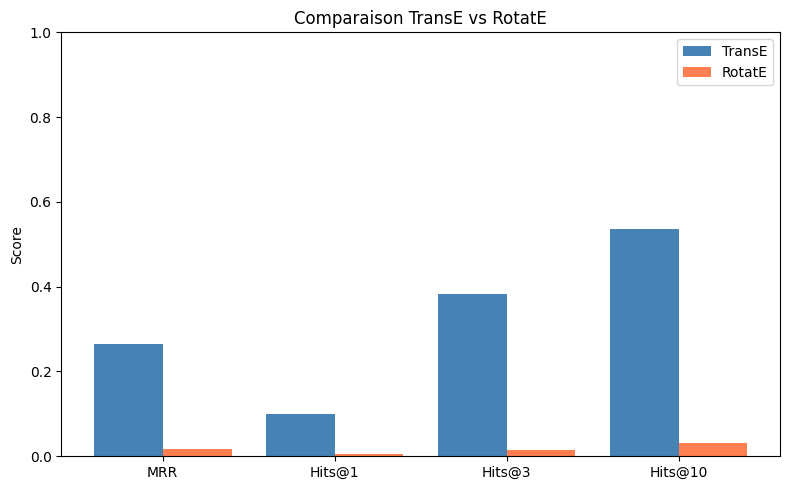

Graphique sauvegarde : comparaison_modeles.png


In [20]:
print("=" * 45)
print(f"{'Metrique':<12} {'TransE':>10} {'RotatE':>10} {'Meilleur':>10}")
print("-" * 45)

metriques = [
    ("MRR",     mrr_transe, mrr_rotate),
    ("Hits@1",  h1_transe,  h1_rotate),
    ("Hits@3",  h3_transe,  h3_rotate),
    ("Hits@10", h10_transe, h10_rotate),
]

for nom, val_transe, val_rotate in metriques:
    meilleur = "RotatE" if val_rotate > val_transe else "TransE"
    print(f"{nom:<12} {val_transe:>10.4f} {val_rotate:>10.4f} {meilleur:>10}")

print("=" * 45)

# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))
x = ["MRR", "Hits@1", "Hits@3", "Hits@10"]
transe_vals = [mrr_transe, h1_transe, h3_transe, h10_transe]
rotate_vals = [mrr_rotate, h1_rotate, h3_rotate, h10_rotate]

x_pos = range(len(x))
ax.bar([i - 0.2 for i in x_pos], transe_vals, width=0.4, label="TransE", color="steelblue")
ax.bar([i + 0.2 for i in x_pos], rotate_vals, width=0.4, label="RotatE", color="coral")

ax.set_xticks(x_pos)
ax.set_xticklabels(x)
ax.set_ylabel("Score")
ax.set_title("Comparaison TransE vs RotatE")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(CHEMIN + "comparaison_modeles.png", dpi=150)
plt.show()
print("Graphique sauvegarde : comparaison_modeles.png")

### 7. Sensibilité à la taille de la KB

On entraîne TransE sur 3 sous-ensembles pour voir comment la taille
de la KB influence les performances.

In [21]:
resultats_taille = {}

for taille, n_triplets in [("20k", 20000), ("50k", 50000), ("full", len(train_raw))]:
    print(f"\nEntrainement sur {taille} triplets...")

    # Sous-ensemble
    sous_ensemble = train_raw[:n_triplets]
    chemin_sous = CHEMIN + f"train_{taille}.txt"
    sauvegarder_triplets(sous_ensemble, chemin_sous)

    tf_sous = TriplesFactory.from_path(chemin_sous)

    # On filtre valid/test pour ne garder que les entites connues
    entites_sous = set([t[0] for t in sous_ensemble] + [t[2] for t in sous_ensemble])
    valid_sous = [(s,p,o) for s,p,o in valid_propre if s in entites_sous and o in entites_sous]
    test_sous  = [(s,p,o) for s,p,o in test_propre  if s in entites_sous and o in entites_sous]

    if len(valid_sous) < 10 or len(test_sous) < 10:
        print(f"  Pas assez de triplets valid/test pour {taille}, on passe.")
        continue

    chemin_valid_sous = CHEMIN + f"valid_{taille}.txt"
    chemin_test_sous  = CHEMIN + f"test_{taille}.txt"
    sauvegarder_triplets(valid_sous, chemin_valid_sous)
    sauvegarder_triplets(test_sous,  chemin_test_sous)

    tf_v = TriplesFactory.from_path(chemin_valid_sous,
        entity_to_id=tf_sous.entity_to_id,
        relation_to_id=tf_sous.relation_to_id)
    tf_t = TriplesFactory.from_path(chemin_test_sous,
        entity_to_id=tf_sous.entity_to_id,
        relation_to_id=tf_sous.relation_to_id)

    res = pipeline(
        training=tf_sous, validation=tf_v, testing=tf_t,
        model="TransE",
        model_kwargs=dict(embedding_dim=128),
        optimizer_kwargs=dict(lr=0.01),
        training_kwargs=dict(num_epochs=30, batch_size=512),
        negative_sampler_kwargs=dict(num_negs_per_pos=10),
        evaluation_kwargs=dict(batch_size=64),
        random_seed=42, device="cpu",
    )

    resultats_taille[taille] = {
        "triplets": n_triplets,
        "MRR":      res.get_metric("mean_reciprocal_rank"),
        "Hits@1":   res.get_metric("hits_at_1"),
        "Hits@10":  res.get_metric("hits_at_10"),
    }
    print(f"  MRR={resultats_taille[taille]['MRR']:.4f}  Hits@10={resultats_taille[taille]['Hits@10']:.4f}")

print()
print("RESULTATS PAR TAILLE :")
print(f"{'Taille':<8} {'Triplets':>10} {'MRR':>8} {'Hits@1':>8} {'Hits@10':>8}")
print("-" * 46)
for taille, r in resultats_taille.items():
    print(f"{taille:<8} {r['triplets']:>10} {r['MRR']:>8.4f} {r['Hits@1']:>8.4f} {r['Hits@10']:>8.4f}")


Entrainement sur 20k triplets...


INFO:pykeen.pipeline.api:Using device: cpu
Training batches on cpu:  20%|██        | 8/40 [00:00<00:00, 75.38batch/s]


Training batches on cpu:  88%|████████▊ | 35/40 [00:00<00:00, 77.46batch/s]


Training epochs on cpu: 100%|██████████| 30/30 [00:20<00:00,  1.45epoch/s, loss=5.25e-5, prev_loss=5.35e-5]
Evaluating on cpu: 100%|██████████| 5.49k/5.49k [00:18<00:00, 304triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 18.12s seconds


  MRR=0.1260  Hits@10=0.2672

Entrainement sur 50k triplets...


...

Training batches on cpu:  95%|█████████▌| 106/111 [00:01<00:00, 56.60batch/s]


Training batches on cpu:   5%|▌         | 6/111 [00:00<00:02, 50.28batch/s]


Training batches on cpu:  17%|█▋        | 19/111 [00:00<00:01, 57.22batch/s]


Training epochs on cpu: 100%|██████████| 30/30 [01:04<00:00,  2.15s/epoch, loss=0.000121, prev_loss=0.000127]
Evaluating on cpu: 100%|██████████| 6.15k/6.15k [00:33<00:00, 186triple/s]
INFO:pykeen.evaluation.evaluator:Evaluation took 33.29s seconds


  MRR=0.1657  Hits@10=0.3956

RESULTATS PAR TAILLE :
Taille     Triplets      MRR   Hits@1  Hits@10
----------------------------------------------
20k           20000   0.1260   0.0507   0.2672
50k           50000   0.1686   0.0474   0.3784
full          56762   0.1657   0.0396   0.3956


### 8. Analyse des embeddings : Voisins les plus proches

In [22]:
# On utilise le meilleur modele pour l'analyse
meilleur_result = result_rotate if mrr_rotate > mrr_transe else result_transe
meilleur_nom    = "RotatE" if mrr_rotate > mrr_transe else "TransE"
print(f"Meilleur modele : {meilleur_nom}")

# Extraction des embeddings d'entites
modele = meilleur_result.model
entity_embeddings = modele.entity_representations[0](indices=None).detach().cpu().numpy()
entity_to_id      = tf_train.entity_to_id
id_to_entity      = {v: k for k, v in entity_to_id.items()}

def get_nom_court(uri):
    """Extrait un nom lisible depuis une URI."""
    return uri.split("/")[-1].replace("_", " ")[:30]

def voisins_proches(entite_uri, k=5):
    """Trouve les k entites les plus proches dans l'espace vectoriel."""
    if entite_uri not in entity_to_id:
        print(f"Entite non trouvee : {entite_uri}")
        return

    idx = entity_to_id[entite_uri]
    vec = entity_embeddings[idx]

    # Distance cosinus avec toutes les autres entites
    norms = np.linalg.norm(entity_embeddings, axis=1)
    norms[norms == 0] = 1
    similarities = entity_embeddings @ vec / (norms * np.linalg.norm(vec))

    # Top k (en excluant l'entite elle-meme)
    top_k = np.argsort(similarities)[::-1][1:k+1]

    nom = get_nom_court(entite_uri)
    print(f"Voisins les plus proches de '{nom}' :")
    for i, idx_voisin in enumerate(top_k):
        voisin_uri = id_to_entity[idx_voisin]
        sim = similarities[idx_voisin]
        print(f"  {i+1}. {get_nom_court(voisin_uri):<35} (similarite={sim:.3f})")
    print()

# Test sur quelques artistes de notre KB
artistes_test = [
    "http://musickg.example.org/resource/The_Beatles",
    "http://musickg.example.org/resource/Daft_Punk",
    "http://musickg.example.org/resource/Radiohead",
    "http://musickg.example.org/resource/Eminem",
]

for artiste in artistes_test:
    voisins_proches(artiste, k=5)

Meilleur modele : TransE
Voisins les plus proches de 'The Beatles' :
  1. Q1299                               (similarite=0.801)
  2. Bob Dylan                           (similarite=0.630)
  3. The Strokes                         (similarite=0.621)
  4. Rolling Stones                      (similarite=0.606)
  5. Queen                               (similarite=0.604)

Voisins les plus proches de 'Daft Punk' :
  1. Massive Attack                      (similarite=0.679)
  2. Joy Division                        (similarite=0.631)
  3. Air                                 (similarite=0.598)
  4. Eminem                              (similarite=0.590)
  5. Jacques Brel                        (similarite=0.589)

Voisins les plus proches de 'Radiohead' :
  1. Air                                 (similarite=0.627)
  2. Pink Floyd                          (similarite=0.583)
  3. Label Parlophone                    (similarite=0.580)
  4. Amy Winehouse                       (similarite=0.579)
  5. 

### 9. Visualisation t-SNE

Entites de notre KB : 343
Application du t-SNE...


C:\Users\sandy\anaconda3\envs\rstudio\lib\site-packages\sklearn\manifold\_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
C:\Users\sandy\anaconda3\envs\rstudio\lib\site-packages\sklearn\manifold\_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


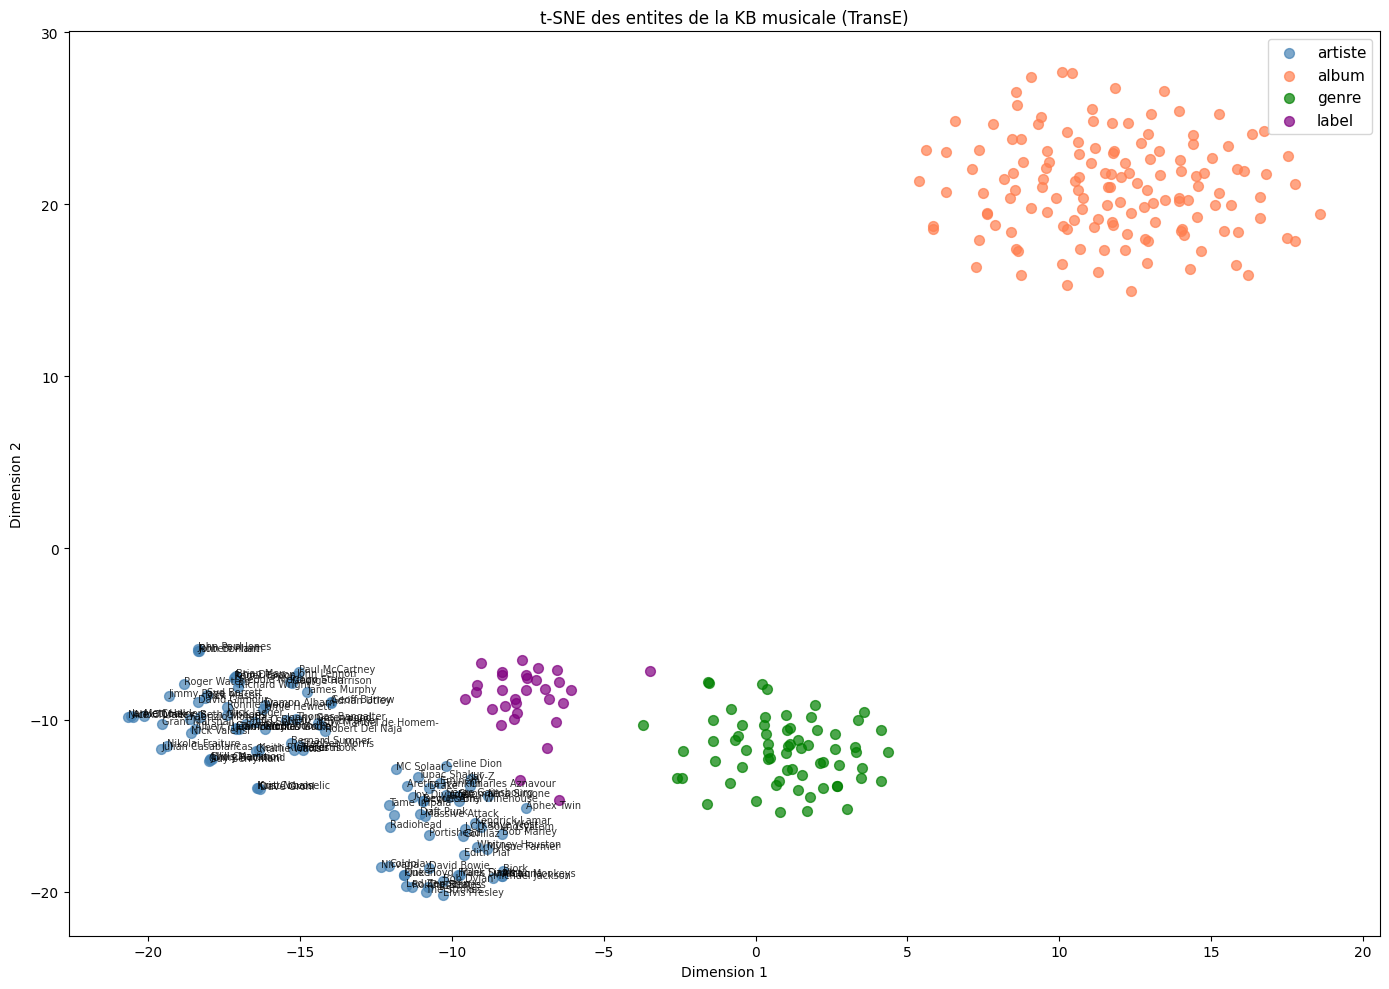

Graphique sauvegarde : tsne_kb.png


In [23]:
# On visualise un sous-ensemble d'entites pour que ce soit lisible
# On prend les entites de notre KB privee (artistes, albums, genres)

PREFIX_EX = "http://musickg.example.org/resource/"

# Collecte des entites de notre KB avec leur type
entites_kb = []
labels_kb  = []
couleurs_map = {
    "artiste": "steelblue",
    "album":   "coral",
    "genre":   "green",
    "label":   "purple",
    "autre":   "gray"
}

for uri, idx in entity_to_id.items():
    if not uri.startswith(PREFIX_EX):
        continue
    nom = uri.replace(PREFIX_EX, "")
    if nom.startswith("Album_"):
        type_entite = "album"
    elif nom.startswith("Genre_"):
        type_entite = "genre"
    elif nom.startswith("Label_"):
        type_entite = "label"
    elif nom.startswith("Country_"):
        continue  # on ignore les pays
    else:
        type_entite = "artiste"

    entites_kb.append((idx, nom.replace("_", " ")[:20], type_entite))

print(f"Entites de notre KB : {len(entites_kb)}")

# Extraction des vecteurs
indices = [e[0] for e in entites_kb]
noms    = [e[1] for e in entites_kb]
types   = [e[2] for e in entites_kb]

vecteurs = entity_embeddings[indices]

# t-SNE : reduction en 2D
print("Application du t-SNE...")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(vecteurs)-1))
coords_2d = tsne.fit_transform(vecteurs)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 10))

for type_entite, couleur in couleurs_map.items():
    masque = [i for i, t in enumerate(types) if t == type_entite]
    if masque:
        ax.scatter(
            coords_2d[masque, 0],
            coords_2d[masque, 1],
            c=couleur, label=type_entite, alpha=0.7, s=50
        )

# On annote les artistes principaux
for i, (nom, type_e) in enumerate(zip(noms, types)):
    if type_e == "artiste" and len(nom) > 3:
        ax.annotate(nom, (coords_2d[i, 0], coords_2d[i, 1]),
                    fontsize=7, alpha=0.8)

ax.legend(fontsize=11)
ax.set_title(f"t-SNE des entites de la KB musicale ({meilleur_nom})")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
plt.tight_layout()
plt.savefig(CHEMIN + "tsne_kb.png", dpi=150)
plt.show()
print("Graphique sauvegarde : tsne_kb.png")

### 10. Analyse des types de relations

On analyse comment les modèles gèrent les différents types de relations
présents dans notre KB musicale.

In [24]:
# Extraction des embeddings de relations
relation_embeddings = meilleur_result.model.relation_representations[0](indices=None).detach().cpu().numpy()
relation_to_id      = tf_train.relation_to_id
id_to_relation      = {v: k for k, v in relation_to_id.items()}

def get_rel_nom(uri):
    return uri.split("/")[-1][:30]

# Analyse 1 : relations symetriques
# Pour une relation symetrique r, on s'attend a ce que vec(r) ≈ -vec(r)
# Ce qui signifie que la norme de vec(r) doit etre proche de 0
print("Analyse des relations symetriques (collaboratedWith) :")
print("Pour TransE, une relation symetrique devrait avoir une norme proche de 0.")
print()

PREFIX_EXO = "http://musickg.example.org/ontology/"
relations_interets = [
    f"{PREFIX_EXO}collaboratedWith",
    f"{PREFIX_EXO}influencedBy",
    f"{PREFIX_EXO}hasGenre",
    f"{PREFIX_EXO}signedTo",
    f"{PREFIX_EXO}hasMember",
]

print(f"{'Relation':<25} {'Norme':>8} {'Type'}")
print("-" * 50)
for rel_uri in relations_interets:
    if rel_uri in relation_to_id:
        idx = relation_to_id[rel_uri]
        vec = relation_embeddings[idx]
        norme = np.linalg.norm(vec)
        nom = get_rel_nom(rel_uri)
        type_rel = "symetrique" if rel_uri.endswith("collaboratedWith") else "asymetrique"
        print(f"{nom:<25} {norme:>8.4f}  {type_rel}")



Analyse des relations symetriques (collaboratedWith) :
Pour TransE, une relation symetrique devrait avoir une norme proche de 0.

Relation                     Norme Type
--------------------------------------------------
influencedBy                1.4880  asymetrique
hasGenre                    1.8026  asymetrique
signedTo                    2.0183  asymetrique
hasMember                   1.4436  asymetrique


### 11. Exercice 8 : règle SWRL vs embedding

Notre règle SWRL de transitivité :
$$\text{influencedBy}(A,B) \wedge \text{influencedBy}(B,C) \Rightarrow \text{influencedBy}(A,C)$$

L'équivalent vectoriel avec TransE :
$$\vec{r}_{\text{influencedBy}}(A,B) + \vec{r}_{\text{influencedBy}}(B,C) \approx \vec{r}_{\text{influencedBy}}(A,C)$$

In [25]:
# Test : Nirvana influencedBy The Beatles influencedBy Elvis Presley
# → est-ce que vec(Nirvana) + vec(influencedBy) ≈ vec(Elvis Presley) ?

EX_BASE = "http://musickg.example.org/resource/"
EXO_BASE = "http://musickg.example.org/ontology/"

# On utilise les embeddings TransE pour cet exercice
modele_transe = result_transe.model
e_emb = modele_transe.entity_representations[0](indices=None).detach().cpu().numpy()
r_emb = modele_transe.relation_representations[0](indices=None).detach().cpu().numpy()
e2id  = tf_train.entity_to_id
r2id  = tf_train.relation_to_id

def get_vec_entite(nom_uri):
    if nom_uri in e2id:
        return e_emb[e2id[nom_uri]]
    return None

def get_vec_relation(rel_uri):
    if rel_uri in r2id:
        return r_emb[r2id[rel_uri]]
    return None

rel_inf = get_vec_relation(EXO_BASE + "influencedBy")
vec_nirvana = get_vec_entite(EX_BASE + "Nirvana")
vec_beatles = get_vec_entite(EX_BASE + "The_Beatles")
vec_elvis   = get_vec_entite(EX_BASE + "Elvis_Presley")

if all(v is not None for v in [rel_inf, vec_nirvana, vec_beatles, vec_elvis]):
    # Composition : vec(Nirvana) + vec(influencedBy) + vec(influencedBy)
    compose = vec_nirvana + rel_inf + rel_inf

    # Distance avec vec(Elvis)
    dist = np.linalg.norm(compose - vec_elvis)

    # Similarite cosinus
    sim = np.dot(compose, vec_elvis) / (np.linalg.norm(compose) * np.linalg.norm(vec_elvis))

    print("Test de la regle de transitivite dans l'espace vectoriel :")
    print()
    print("  Nirvana influencedBy The Beatles influencedBy Elvis Presley")
    print(f"  → vec(Nirvana) + 2*vec(influencedBy) ≈ vec(Elvis Presley) ?")
    print()
    print(f"  Distance L2     : {dist:.4f}")
    print(f"  Similarite cos  : {sim:.4f}")
    print()
    if sim > 0.5:
        print("  Resultat : OUI, l'embedding capture la transitivite")
    else:
        print("  Resultat : partiel — l'embedding ne capture pas parfaitement la transitivite")
        print("  Cela montre la limite des modeles TransE sur les relations composees")
else:
    print("Certaines entites ne sont pas dans le graphe d'entrainement")

Test de la regle de transitivite dans l'espace vectoriel :

  Nirvana influencedBy The Beatles influencedBy Elvis Presley
  → vec(Nirvana) + 2*vec(influencedBy) ≈ vec(Elvis Presley) ?

  Distance L2     : 2.9343
  Similarite cos  : 0.0921

  Resultat : partiel — l'embedding ne capture pas parfaitement la transitivite
  Cela montre la limite des modeles TransE sur les relations composees


### 12. Sauvegarde des résultats

In [26]:
resultats_finaux = {
    "TransE": {
        "MRR":    mrr_transe,
        "Hits@1": h1_transe,
        "Hits@3": h3_transe,
        "Hits@10":h10_transe,
        "config": {"embedding_dim": 128, "epochs": 50, "lr": 0.01, "batch_size": 512}
    },
    "RotatE": {
        "MRR":    mrr_rotate,
        "Hits@1": h1_rotate,
        "Hits@3": h3_rotate,
        "Hits@10":h10_rotate,
        "config": {"embedding_dim": 128, "epochs": 50, "lr": 0.01, "batch_size": 512}
    },
    "size_sensitivity": resultats_taille
}

with open(CHEMIN + "kge_resultats.json", "w") as f:
    json.dump(resultats_finaux, f, indent=2)

print("Resultats sauvegardes : kge_resultats.json")

# Sauvegarde des modeles
result_transe.save_to_directory(CHEMIN + "model_transe")
result_rotate.save_to_directory(CHEMIN + "model_rotate")
print("Modeles sauvegardes : model_transe/, model_rotate/")

Resultats sauvegardes : kge_resultats.json


INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=16505, num_relations=56, num_triples=56762, inverse_triples=False, path="C:\Users\sandy\OneDrive\Desktop\Cours A4\Web Datamining\TD4_Project\train.txt") to file:///C:/Users/sandy/OneDrive/Desktop/Cours%20A4/Web%20Datamining/TD4_Project/model_transe/training_triples
INFO:pykeen.pipeline.api:Saved to directory: file:///C:/Users/sandy/OneDrive/Desktop/Cours%20A4/Web%20Datamining/TD4_Project/model_transe
INFO:pykeen.triples.triples_factory:Stored TriplesFactory(num_entities=16505, num_relations=56, num_triples=56762, inverse_triples=False, path="C:\Users\sandy\OneDrive\Desktop\Cours A4\Web Datamining\TD4_Project\train.txt") to file:///C:/Users/sandy/OneDrive/Desktop/Cours%20A4/Web%20Datamining/TD4_Project/model_rotate/training_triples
INFO:pykeen.pipeline.api:Saved to directory: file:///C:/Users/sandy/OneDrive/Desktop/Cours%20A4/Web%20Datamining/TD4_Project/model_rotate


Modeles sauvegardes : model_transe/, model_rotate/
